**Physics-Informed Neural Network for the Lotka-Volterra System**

This notebook generates Lotka-Volterra predator-prey data and trains a PINN to recover both the state trajectories and the physical parameters.

Lotka-Volterra equations:

`dx/dt = alpha*x - beta*x*y`

`dy/dt = delta*x*y - gamma*y`

The neural network predicts `[x(t), y(t)]`. PyTorch autograd computes time derivatives, and the loss penalizes both data mismatch and equation residuals.

In [1]:
import importlib.util

if importlib.util.find_spec('torch') is None:
    raise ImportError(
        "PyTorch is required for this PINN notebook. Install it in the project venv with:\n"
        "    venv\\Scripts\\python.exe -m pip install torch\n"
        "Then restart the notebook kernel and run again."
    )

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(7)
torch.manual_seed(7)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


**Generate Lotka-Volterra data**

The simulation uses the same time horizon, initial condition, and parameters as `Lotka_Voltera.ipynb`. A fourth-order Runge-Kutta solver is used for cleaner training data.

In [2]:
tf = 20.0
dt = 0.01
steps = int(tf / dt)
t = np.arange(steps, dtype=np.float32).reshape(-1, 1) * dt

alpha_true = 1.0
beta_true = 0.2
delta_true = 0.1
gamma_true = 0.2
x0 = np.array([8.0, 8.0], dtype=np.float32)

def lotka_volterra_rhs(state, alpha=alpha_true, beta=beta_true, delta=delta_true, gamma=gamma_true):
    prey, predator = state
    return np.array([
        alpha * prey - beta * prey * predator,
        delta * prey * predator - gamma * predator,
    ], dtype=np.float32)

states = np.zeros((steps, 2), dtype=np.float32)
states[0] = x0

for i in range(1, steps):
    s = states[i - 1]
    k1 = lotka_volterra_rhs(s)
    k2 = lotka_volterra_rhs(s + 0.5 * dt * k1)
    k3 = lotka_volterra_rhs(s + 0.5 * dt * k2)
    k4 = lotka_volterra_rhs(s + dt * k3)
    states[i] = s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

noise_std = 0.0
measured = states + noise_std * np.random.randn(*states.shape).astype(np.float32)

print('Data shape:', measured.shape)
print('True parameters:', {
    'alpha': alpha_true,
    'beta': beta_true,
    'delta': delta_true,
    'gamma': gamma_true,
})

Data shape: (2000, 2)
True parameters: {'alpha': 1.0, 'beta': 0.2, 'delta': 0.1, 'gamma': 0.2}


**Normalize data for stable training**

In [3]:
t_min = t.min()
t_max = t.max()
t_norm = 2.0 * (t - t_min) / (t_max - t_min) - 1.0

y_mean = measured.mean(axis=0, keepdims=True)
y_std = measured.std(axis=0, keepdims=True)
y_norm = (measured - y_mean) / y_std

t_train = torch.tensor(t_norm, dtype=torch.float32, device=device, requires_grad=True)
y_train = torch.tensor(y_norm, dtype=torch.float32, device=device)
y_mean_t = torch.tensor(y_mean, dtype=torch.float32, device=device)
y_std_t = torch.tensor(y_std, dtype=torch.float32, device=device)
dt_norm_dt = torch.tensor(2.0 / (t_max - t_min), dtype=torch.float32, device=device)

print('State mean:', y_mean.ravel())
print('State std:', y_std.ravel())

State mean: [2.1092243 5.7365327]
State std: [2.8043451 3.5360384]


**Define the Lotka-Volterra PINN**

`alpha`, `beta`, `delta`, and `gamma` are positive trainable parameters.

In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim=1, out_dim=2, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class LotkaVolterraPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.state_net = MLP()
        self.softplus = nn.Softplus()

        # Store inverse-Softplus values so the positive physical parameters
        # start at the values used in the original WyNDA notebook.
        self.raw_alpha = nn.Parameter(self.inverse_softplus(torch.tensor(alpha_true)))
        self.raw_beta = nn.Parameter(self.inverse_softplus(torch.tensor(beta_true)))
        self.raw_delta = nn.Parameter(self.inverse_softplus(torch.tensor(delta_true)))
        self.raw_gamma = nn.Parameter(self.inverse_softplus(torch.tensor(gamma_true)))

    @staticmethod
    def inverse_softplus(value):
        return torch.log(torch.expm1(value))

    def parameters_physical(self):
        alpha = self.softplus(self.raw_alpha)
        beta = self.softplus(self.raw_beta)
        delta = self.softplus(self.raw_delta)
        gamma = self.softplus(self.raw_gamma)
        return alpha, beta, delta, gamma

    def forward(self, t_in):
        y_hat_norm = self.state_net(t_in)
        y_hat = y_mean_t + y_std_t * y_hat_norm
        alpha, beta, delta, gamma = self.parameters_physical()
        return y_hat_norm, y_hat, alpha, beta, delta, gamma


model = LotkaVolterraPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

**Train the PINN**

The data loss fits the simulated measurements. The physics loss enforces the predator-prey equations at randomly sampled time points.

In [5]:
EPOCHS = 10000
PHYSICS_BATCH = 1024
lambda_data = 1.0
lambda_physics = 0.05

history = []

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    y_hat_norm, _, alpha, beta, delta, gamma = model(t_train)
    loss_data = torch.mean((y_hat_norm - y_train) ** 2)

    idx = torch.randint(0, steps, (min(PHYSICS_BATCH, steps),), device=device)
    t_phys = t_train[idx].clone().detach().requires_grad_(True)
    _, y_phys, alpha, beta, delta, gamma = model(t_phys)

    prey = y_phys[:, 0:1]
    predator = y_phys[:, 1:2]

    dprey_dt_norm = torch.autograd.grad(prey, t_phys, grad_outputs=torch.ones_like(prey), create_graph=True)[0]
    dpredator_dt_norm = torch.autograd.grad(predator, t_phys, grad_outputs=torch.ones_like(predator), create_graph=True)[0]

    dprey_dt = dprey_dt_norm * dt_norm_dt
    dpredator_dt = dpredator_dt_norm * dt_norm_dt

    r1 = dprey_dt - (alpha * prey - beta * prey * predator)
    r2 = dpredator_dt - (delta * prey * predator - gamma * predator)
    loss_physics = torch.mean(r1 ** 2 + r2 ** 2)

    loss = lambda_data * loss_data + lambda_physics * loss_physics
    loss.backward()
    optimizer.step()

    if epoch == 1 or epoch % 500 == 0:
        row = [epoch, loss.item(), loss_data.item(), loss_physics.item(), alpha.item(), beta.item(), delta.item(), gamma.item()]
        history.append(row)
        print(
            f'Epoch {epoch:5d} | loss={loss.item():.6f} | data={loss_data.item():.6f} | '
            f'physics={loss_physics.item():.6f} | alpha={alpha.item():.4f} | '
            f'beta={beta.item():.4f} | delta={delta.item():.4f} | gamma={gamma.item():.4f}'
        )

Epoch     1 | loss=1.010717 | data=1.004409 | physics=0.126147 | alpha=1.0000 | beta=0.2000 | delta=0.1000 | gamma=0.2000
Epoch   500 | loss=0.001326 | data=0.000552 | physics=0.015478 | alpha=0.9873 | beta=0.1895 | delta=0.0916 | gamma=0.1917
Epoch  1000 | loss=0.000512 | data=0.000198 | physics=0.006287 | alpha=0.9841 | beta=0.1974 | delta=0.0995 | gamma=0.1991
Epoch  1500 | loss=0.000032 | data=0.000008 | physics=0.000482 | alpha=0.9929 | beta=0.1989 | delta=0.1000 | gamma=0.2004
Epoch  2000 | loss=0.000063 | data=0.000025 | physics=0.000753 | alpha=0.9974 | beta=0.1996 | delta=0.1000 | gamma=0.2001
Epoch  2500 | loss=0.000093 | data=0.000036 | physics=0.001143 | alpha=0.9991 | beta=0.1999 | delta=0.0999 | gamma=0.2000
Epoch  3000 | loss=0.000175 | data=0.000127 | physics=0.000967 | alpha=0.9996 | beta=0.2000 | delta=0.0999 | gamma=0.1999
Epoch  3500 | loss=0.000060 | data=0.000043 | physics=0.000350 | alpha=0.9998 | beta=0.2000 | delta=0.1000 | gamma=0.2000
Epoch  4000 | loss=0.000

**Evaluate the learned trajectory and parameters**

In [6]:
model.eval()
with torch.no_grad():
    _, pred_t, alpha_hat, beta_hat, delta_hat, gamma_hat = model(torch.tensor(t_norm, dtype=torch.float32, device=device))
    pred = pred_t.cpu().numpy()

rmse_measured = np.sqrt(np.mean((measured - pred) ** 2, axis=0))
rmse_clean = np.sqrt(np.mean((states - pred) ** 2, axis=0))

print('RMSE vs measured [prey, predator]:', rmse_measured)
print('RMSE vs clean    [prey, predator]:', rmse_clean)
print('\nTrue parameters:')
print(f'alpha={alpha_true:.6f}, beta={beta_true:.6f}, delta={delta_true:.6f}, gamma={gamma_true:.6f}')
print('Learned parameters:')
print(f'alpha={alpha_hat.item():.6f}, beta={beta_hat.item():.6f}, delta={delta_hat.item():.6f}, gamma={gamma_hat.item():.6f}')

RMSE vs measured [prey, predator]: [0.03926082 0.0231054 ]
RMSE vs clean    [prey, predator]: [0.03926082 0.0231054 ]

True parameters:
alpha=1.000000, beta=0.200000, delta=0.100000, gamma=0.200000
Learned parameters:
alpha=0.999905, beta=0.199975, delta=0.099992, gamma=0.199977


**Plots**

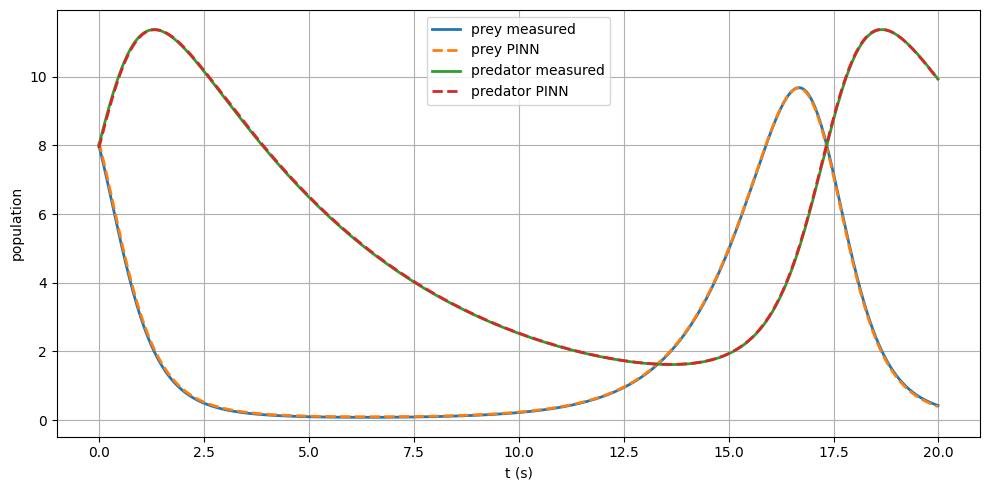

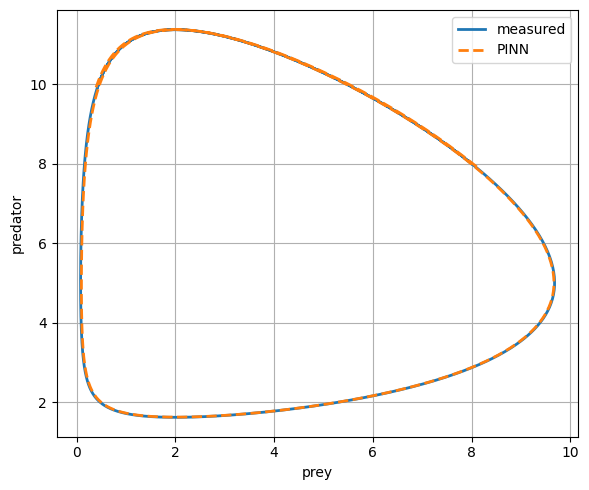

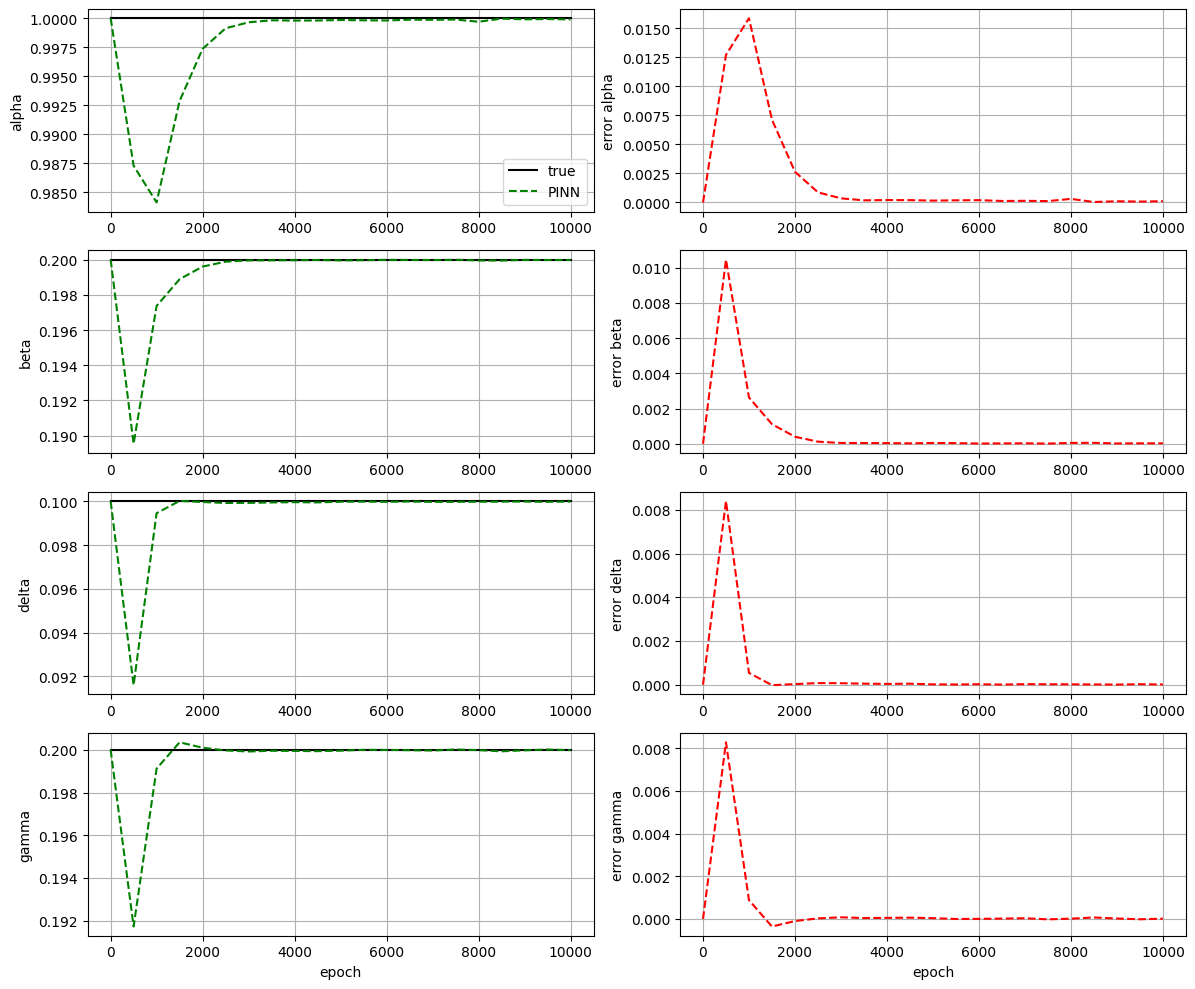

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(t, measured[:, 0], linewidth=2, label='prey measured')
plt.plot(t, pred[:, 0], '--', linewidth=2, label='prey PINN')
plt.plot(t, measured[:, 1], linewidth=2, label='predator measured')
plt.plot(t, pred[:, 1], '--', linewidth=2, label='predator PINN')
plt.grid(True)
plt.xlabel('t (s)')
plt.ylabel('population')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(measured[:, 0], measured[:, 1], linewidth=2, label='measured')
plt.plot(pred[:, 0], pred[:, 1], '--', linewidth=2, label='PINN')
plt.grid(True)
plt.xlabel('prey')
plt.ylabel('predator')
plt.legend()
plt.tight_layout()
plt.show()

history_arr = np.array(history)
if len(history_arr) > 0:
    fig, axs = plt.subplots(4, 2, figsize=(12, 10))
    names = ['alpha', 'beta', 'delta', 'gamma']
    true_values = [alpha_true, beta_true, delta_true, gamma_true]
    learned_cols = [4, 5, 6, 7]

    for i, (name, true_value, col) in enumerate(zip(names, true_values, learned_cols)):
        axs[i, 0].plot(history_arr[:, 0], true_value * np.ones_like(history_arr[:, 0]), 'k', label='true')
        axs[i, 0].plot(history_arr[:, 0], history_arr[:, col], 'g--', label='PINN')
        axs[i, 0].set_ylabel(name)
        axs[i, 0].grid(True)
        if i == 0:
            axs[i, 0].legend()

        axs[i, 1].plot(history_arr[:, 0], true_value - history_arr[:, col], 'r--')
        axs[i, 1].set_ylabel(f'error {name}')
        axs[i, 1].grid(True)

    axs[-1, 0].set_xlabel('epoch')
    axs[-1, 1].set_xlabel('epoch')
    plt.tight_layout()
    plt.show()

**Optional LBFGS refinement**

Run this after Adam training if you want a closer fit. It evaluates the physics residual on all time points, so it can be slower.

In [8]:
RUN_LBFGS = False

if RUN_LBFGS:
    lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=500, tolerance_grad=1e-7, tolerance_change=1e-9)

    def closure():
        lbfgs.zero_grad()
        y_hat_norm, y_hat, alpha, beta, delta, gamma = model(t_train)
        loss_data = torch.mean((y_hat_norm - y_train) ** 2)

        prey = y_hat[:, 0:1]
        predator = y_hat[:, 1:2]
        dprey_dt = torch.autograd.grad(prey, t_train, grad_outputs=torch.ones_like(prey), create_graph=True)[0] * dt_norm_dt
        dpredator_dt = torch.autograd.grad(predator, t_train, grad_outputs=torch.ones_like(predator), create_graph=True)[0] * dt_norm_dt

        r1 = dprey_dt - (alpha * prey - beta * prey * predator)
        r2 = dpredator_dt - (delta * prey * predator - gamma * predator)
        loss_physics = torch.mean(r1 ** 2 + r2 ** 2)
        loss = lambda_data * loss_data + lambda_physics * loss_physics
        loss.backward()
        return loss

    final_loss = lbfgs.step(closure)
    print('Final LBFGS loss:', float(final_loss))